In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from pysr import PySRRegressor
import matplotlib.pyplot as plt

[juliapkg] Found dependencies: /home/andre/programing/lamfo/ic_andre_rimes/env/lib/python3.13/site-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /home/andre/programing/lamfo/ic_andre_rimes/env/lib/python3.13/site-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /home/andre/programing/lamfo/ic_andre_rimes/env/lib/python3.13/site-packages/juliapkg/juliapkg.json
[juliapkg] Locating Julia ^1.10.3
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.12.1 to /home/andre/programing/lamfo/ic_andre_rimes/env/julia_env/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloads) yourself.
[juliapkg] Downloading Julia from https://julialang-s3.juli

  Installing known registries into `~/.julia`
       Added `General` registry to ~/.julia/registries
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed DiffRules ─────────────────── v1.15.1
   Installed MicroMamba ────────────────── v0.1.14
   Installed IrrationalConstants ───────── v0.2.6
   Installed ScientificTypesBase ───────── v3.0.0
   Installed Adapt ─────────────────────── v4.4.0
   Installed Tricks ────────────────────── v0.1.12
   Installed Scratch ───────────────────── v1.3.0
   Installed DynamicExpressions ────────── v1.10.3
   Installed PtrArrays ─────────────────── v1.3.0
   Installed TableTraits ───────────────── v1.0.1
   Installed JSON3 ─────────────────────── v1.14.3
   Installed MLJModelInterface ─────────── v1.11.1
   Installed DiffResults ───────────────── v1.1.0
   Installed Preferences ───────────────── v1.5.0
   Installed ADTypes ───────────────────── v1.18.0
   Installed PythonCall ────────────────── v0.9.2

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_excel("./banco de dados daniel.xlsx", "Dataset com TS variável")
df = df[df["w (mm)"] <= 0.4]
df = df.drop("Autor", axis=1)
X = df.drop("w (mm)", axis=1)
y = df["w (mm)"]

In [3]:
X = X.rename(columns=lambda c: c.encode("ascii", "ignore").decode("ascii"))
X.columns = [c.replace("(", "").replace(")", "").replace(" ", "_") for c in X.columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

In [4]:
model = PySRRegressor(
    parsimony=0.015,
    maxsize=20,
    maxdepth=6,
    population_size=50,
    ncycles_per_iteration=4000,
    niterations=500,
    adaptive_parsimony_scaling=100.0,
    deterministic=False,
    parallelism='multithreading',
    progress=True,
    should_optimize_constants=True,
    optimizer_algorithm="BFGS",
    optimizer_nrestarts=5,
    binary_operators=["+", "-", "*", "/", "pow"],
    weight_optimize=0.005,
    verbosity=1,
    constraints={"pow": (0, 3)}
)

model.fit(X_train, y_train)

/home/andre/programing/lamfo/ic_andre_rimes/env/lib/python3.13/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 1.150e+06
Progress: 342 / 15500 total iterations (2.206%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.314e-03  0.000e+00  y = 0.23656
5           3.532e-03  5.004e-02  y = 0.16844 - (Tenso_na_armadura_menos_tension_stiffening_...
                                      MPa * -0.00027154)
7           3.022e-03  7.795e-02  y = 0.14018 - ((Distncia_ao_centro_de_gravidade_da_armadur...
                                      a__mm * Tenso_na_armadura_menos_tension_stiffening_MPa) * ...
                                      -9.317e-06)
9           2.978e-03  7.348e-03  y = 0.11569 - (Distncia_ao_centro_de_gravidade_da_armadura...
                                      __mm * ((Tenso_na_armadura_menos_tension_stiffening_MPa * ...
                      

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '-', ...]"
,unary_operators,None
,expression_spec,None
,niterations,500
,populations,31
,population_size,50
,max_evals,None
,maxsize,20
,maxdepth,6
,warmup_maxsize_by,None


  - outputs/20251019_104215_bV9klq/hall_of_fame.csv


In [5]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

best_eq = model.get_best()
best_equation = best_eq['equation']

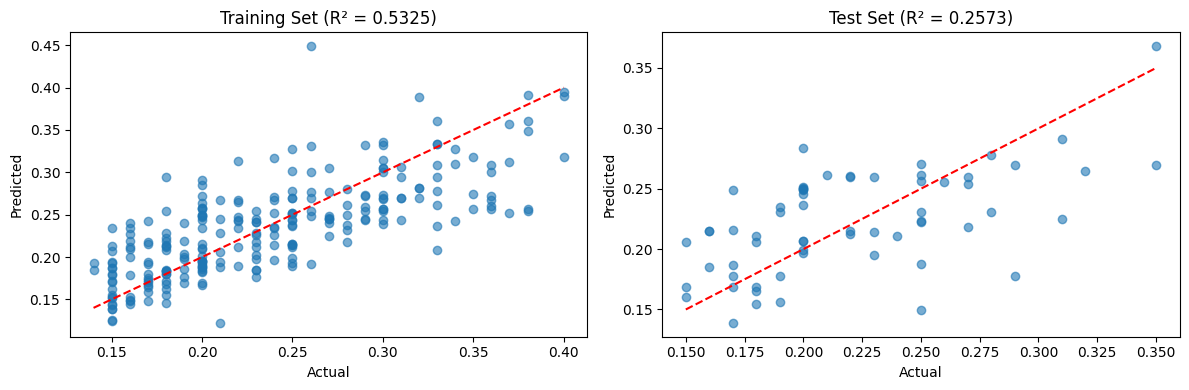

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(y_train, y_pred_train, alpha=0.6)
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
ax1.set_xlabel('Actual')
ax1.set_ylabel('Predicted')
ax1.set_title(f'Training Set (R² = {r2_train:.4f})')

ax2.scatter(y_test, y_pred_test, alpha=0.6)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
ax2.set_title(f'Test Set (R² = {r2_test:.4f})')

plt.tight_layout()
plt.show()

In [7]:
best_eq = model.get_best()
print(f"Best equation: {best_eq['equation']}")
print(f"Complexity: {best_eq['complexity']} nodes")

Best equation: (((Tenso_na_armadura_menos_tension_stiffening_MPa + Espaamento_entre_as_barras_mm) * 1.5137116e-5) * Distncia_ao_centro_de_gravidade_da_armadura__mm) + (-0.068262994 / (Nmero_de_barras_em_uma_camada + -4.6835604))
Complexity: 13 nodes


In [8]:
import sympy as sp
from IPython.display import display, Latex

equation_sympy = model.sympy()
equation_latex = sp.latex(equation_sympy)

table_latex = f"""
\\begin{{array}}{{|l|c|}}
\\hline
\\textbf{{Metric}} & \\textbf{{Value}} \\\\
\\hline
\\text{{Equation}} & {equation_latex} \\\\
\\hline
R^2 \\text{{ (Train)}} & {r2_train:.4f} \\\\
\\hline
R^2 \\text{{ (Test)}} & {r2_test:.4f} \\\\
\\hline
\\text{{RMSE (Train)}} & {rmse_train:.4f} \\\\
\\hline
\\text{{RMSE (Test)}} & {rmse_test:.4f} \\\\
\\hline
\\end{{array}}
"""

display(Latex(table_latex))

<IPython.core.display.Latex object>

In [9]:
models_pred_df = pd.read_excel("banco de dados daniel.xlsx", "Modelos normativos e empíricos")
y_pred_total = model.predict(X)

models_pred_df["Symbolic Regression"] = None  
for i in range(len(y_pred_total)): 
    models_pred_df.at[i, "Symbolic Regression"] = y_pred_total[i]

models_pred_df["Symbolic Regression"] = pd.to_numeric(
    models_pred_df["Symbolic Regression"], errors="coerce"
)

wexp_col = "wexp (mm)"
for col in models_pred_df.select_dtypes(include="number").columns:
    if col == wexp_col:
        continue
    models_pred_df[f"{col} / wexp"] = models_pred_df[col] / models_pred_df[wexp_col]

models_pred_df.drop(columns=['wexp (mm)', 'fib Model Code 2010', 'fib Model Code 2020', 'Eurocode 2',
       'NBR 6118 - wk1 - fissuração estabilizada',
       'NBR 6118 - wk2 - fissuração não estabilizada', 'Clark (1956)',
       'Leonhardt (1977)', 'Desayi e Ganesan (1985)', 'Oh e Kang (1987)',
       'Caldas (1997)', 'Gergely e Lutz (1968)', ' b  variável e < 0,6',
       'equação (15) do artigo de Belarbi e Hsu (1994)',
       'Beta conforme Fields e Bischoff (2004)', 'slip de Yuan et al. (2025)',
       'slip de Biscaia e Soares (2020)', 'HistGradientBoosting_TS_var',
       'LGBM_TS_var', 'GradientBoosting_TS_var', 'HistGradientBoosting_sem_TS',
       'LGBM_sem_TS', 'GradientBoosting_sem_TS', 'Symbolic Regression'], inplace=True)

numeric_df = models_pred_df.select_dtypes(include="number")
desc = numeric_df.describe().T
desc["skewness"] = numeric_df.skew()
desc["kurtosis"] = numeric_df.kurtosis()
desc_rounded = desc.round(2).drop(columns=["count"])
desc_rounded

,mean,std,min,25%,50%,75%,max,skewness,kurtosis
fib Model Code 2010 / wexp,0.86,0.28,0.04,0.67,0.83,1.06,1.56,0.09,0.06
fib Model Code 2020 / wexp,0.85,0.25,0.19,0.67,0.85,1.00,1.57,0.30,0.11
Eurocode 2 / wexp,0.91,0.31,0.24,0.72,0.87,1.08,2.02,0.82,1.27
NBR 6118 - wk1 - fissuração estabilizada / wexp,1.11,0.34,0.24,0.88,1.15,1.36,2.01,-0.13,-0.42
NBR 6118 - wk2 - fissuração não estabilizada / wexp,1.25,0.62,0.20,0.84,1.13,1.60,4.54,1.48,4.16
Clark (1956) / wexp,0.94,0.44,0.16,0.60,0.84,1.17,2.19,0.88,0.28
Leonhardt (1977) / wexp,1.36,0.43,0.17,1.08,1.37,1.61,2.41,-0.17,-0.10
Desayi e Ganesan (1985) / wexp,1.16,0.45,0.40,0.79,1.13,1.48,2.36,0.40,-0.68
Oh e Kang (1987) / wexp,0.88,0.30,0.25,0.65,0.88,1.11,1.55,-0.11,-0.74
Caldas (1997) / wexp,0.81,0.22,0.32,0.68,0.79,0.92,1.68,0.73,1.50
